In [1]:
import os
import json
import glob
import pickle
import datetime
import pandas as pd
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt

import scipy as sp

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 16})

In [2]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

In [3]:
def smooth(y, nWindow, polyOrder=2):
    y_smooth = sp.signal.savgol_filter(y, nWindow, polyOrder, mode='nearest')
    return y_smooth

In [5]:
root_dir = './results'
type_dir = 'fp'
scene_dir = 'scene02'
load_str = datetime.datetime(2023, 12, 15)

load_dir = os.path.join(root_dir, type_dir, scene_dir, f'exp-{load_str.year}-{load_str.month}-{load_str.day}')
file_name = f'{scene_dir}_data.pkl'

In [6]:
save_dir = os.path.join(root_dir, "thesis", type_dir)
os.makedirs(save_dir, exist_ok=True)

In [7]:
with open(os.path.join(load_dir, file_name), 'rb') as file_:
    fp_data = pickle.load(file_)

fp_df = pd.DataFrame.from_dict(fp_data)
print(fp_df.head(5))

        I    K  sig_e  sig_i      ue1      ui1      ue2      ui2 FP_type
0 -15.625 -1.0    2.5    2.5  -7.7586 -31.0480  -7.7586 -31.0480     red
1 -15.625 -1.0    2.5    2.5  -2.7673  -5.6879  -2.7673  -5.6879  purple
2 -15.625 -1.0    2.5    2.5  -3.3039 -13.3167  -2.7566  -5.5316  purple
3 -15.625 -1.0    2.5    2.5 -12.9679 -31.2500  -2.6571  -4.1608  purple
4 -15.625 -1.0    2.5    2.5  -2.6571  -4.1608 -12.9679 -31.2500  purple


In [8]:
I_uniq = fp_df['I'].unique()
sigmae_uniq = fp_df['sig_e'].unique()
sigmai_uniq = fp_df['sig_i'].unique()
K_uniq = fp_df['K'].unique()

nIvals = len(I_uniq)
nSigEvals = len(sigmae_uniq)
nSigIvals = len(sigmai_uniq)
nKvals = len(K_uniq)

print(f"Unique I's = {nIvals} | sigma_e's = {nSigEvals} | sigma_i's = {nSigIvals} | K's = {nKvals}")

Unique I's = 50 | sigma_e's = 50 | sigma_i's = 50 | K's = 50


In [9]:
## Calculate the multi-stability region as delta K vs. sigma for different I values

fileName = 'MultiStable_DeltaK.pkl'

if os.path.isfile(os.path.join(load_dir, fileName)):
    print("File FOUND!")
    with open(os.path.join(load_dir, fileName), 'rb') as f:
        ResultsDict = pickle.load(f)
    
    deltaK_arr = ResultsDict['DeltaK']
    MultiK = ResultsDict['MultiK']

else:

    deltaK_arr = np.zeros((nIvals, nSigEvals, nSigIvals))   # region width in terms of K
    MultiK = np.zeros((nIvals, nSigEvals, nSigIvals))       # no. of multi-stability regions

    for nI in range (0, nIvals):
        I = I_uniq[nI]

        if nI % 10 == 0:
            print(f'Evaluating multi-region width for I = {I:.3f}')
        for nSE, sigE in enumerate(sigmae_uniq):
            for nSI, sigI in enumerate(sigmai_uniq):
            
                df_sub = fp_df[(fp_df['sig_e'] == sigE) & (fp_df['sig_i'] == sigI) & (fp_df['I'] == I)]

                fp_counts_dict = df_sub['K'].value_counts().sort_index().to_dict()

                K = np.array(list(fp_counts_dict.keys()))
                Ksort = np.argsort(K)
                K = K[Ksort]

                FP_count = np.array(list(fp_counts_dict.values()))
                FP_count = FP_count[Ksort]

                MultiR_id = np.where(FP_count > 1)[0]

                if len(MultiR_id) == 0:
                    continue

                Mult_diffid = np.diff(MultiR_id)

                markers = np.where(Mult_diffid > 5)[0] + 1
                nRegions = len(markers)

                # if there are multiple multi-stable regions in the system delta K is claculated as sum of delta K over all regions
                if nRegions:
                    segment_delt = []
                    start_marker = 0

                    for i in range(nRegions + 1):
                        if i !=  nRegions:
                            marker = markers[i]
                            segment = MultiR_id[start_marker:marker]
                        else:
                            segment = MultiR_id[start_marker:]
                        
                        if i < nRegions:
                            start_marker = marker

                        segment_delt.append(K[segment[-1]] - K[segment[0]]) if len(segment) > 0 else 0
                    
                    deltaK_arr[nI, nSE, nSI] = sum(segment_delt)
                    MultiK[nI, nSE, nSI] = len(segment_delt)

                else:
                    MultiK[nI, nSE, nSI] += 1
                    deltaK_arr[nI, nSE, nSI] = K[MultiR_id[-1]] - K[MultiR_id[0]]  

    ResultsDict = {
                    'DeltaK': deltaK_arr,
                    'MultiK': MultiK
                }
    with open(os.path.join(load_dir, fileName), 'wb') as f:
        pickle.dump(ResultsDict, f)     

File FOUND!


In [44]:
deltaK_arr[0, 0, :]

array([0.96, 0.92, 0.88, 0.88, 0.84, 0.84, 0.8 , 0.76, 0.76, 0.72, 0.68,
       0.68, 0.64, 0.6 , 0.6 , 0.56, 0.52, 0.52, 0.48, 0.44, 0.4 , 0.4 ,
       0.36, 0.32, 0.28, 0.28, 0.24, 0.2 , 0.16, 0.16, 0.12, 0.08, 0.08,
       0.04, 0.08, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

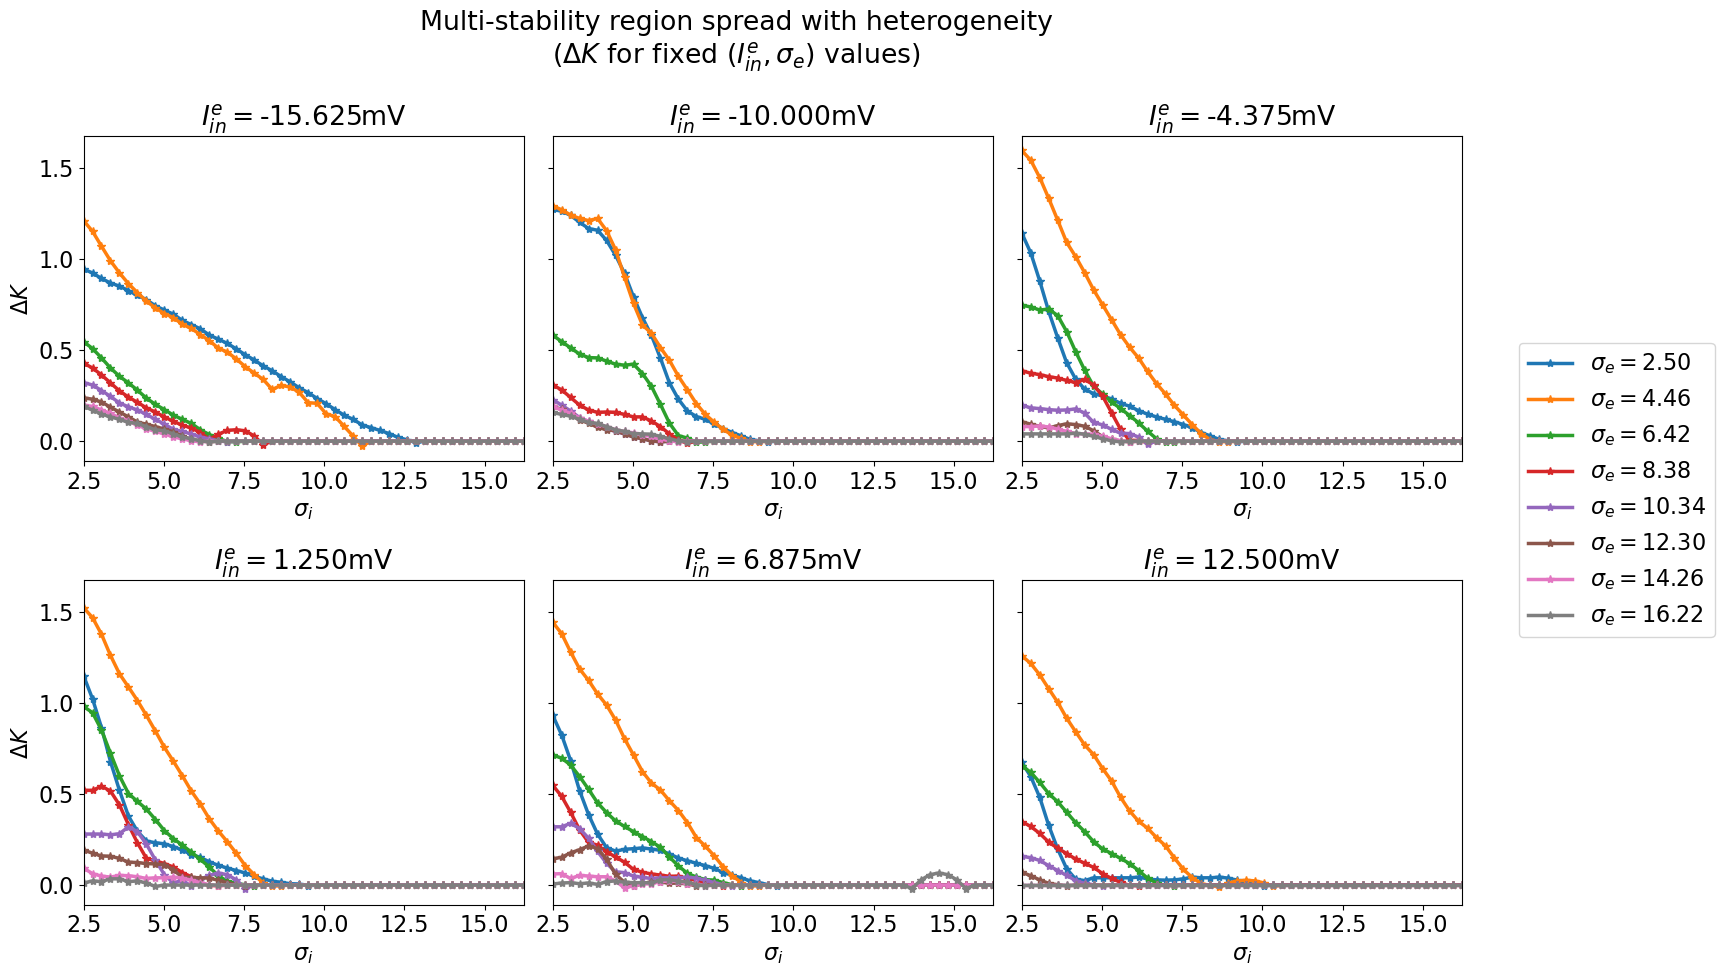

In [56]:
fileName = 'Scene02_MultiStable_DeltaK.png'

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

nRow = 0
nCol = 0

for nI in range(0, nIvals, 9):
    for nSE in range(0, nSigEvals, 7):
        if nRow == 1 and nCol == 2:
            axs[nRow, nCol].plot(sigmai_uniq, smooth(deltaK_arr[nI, nSE, :], 7, 3), '-*', linewidth=2.5, label=r"$\sigma_e = $" + f"{sigmae_uniq[nSE]:.2f}")
        else:
            axs[nRow, nCol].plot(sigmai_uniq, smooth(deltaK_arr[nI, nSE, :], 7, 3), '-*', linewidth=2.5)
    
    axs[nRow, nCol].set_title(r"$I_{in}^e = $" + f"{I_uniq[nI]:.3f}mV")
    axs[nRow, nCol].set_xlabel(r"$\sigma_i$")
    axs[nRow, nCol].set_xlim(sigmai_uniq[0], sigmai_uniq[-1])

    if nCol == 0:
        axs[nRow, nCol].set_ylabel(r"$\Delta K$")
    
    if nCol < 2:
        nCol += 1
    else:
        nCol = 0
        nRow += 1

fig.legend(loc = 'center right', bbox_to_anchor=(1.16, 0.5))
plt.suptitle("Multi-stability region spread with heterogeneity\n" + r"($\Delta K$ for fixed $(I_{in}^e, \sigma_e)$ values)")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), dpi=600)
plt.show()

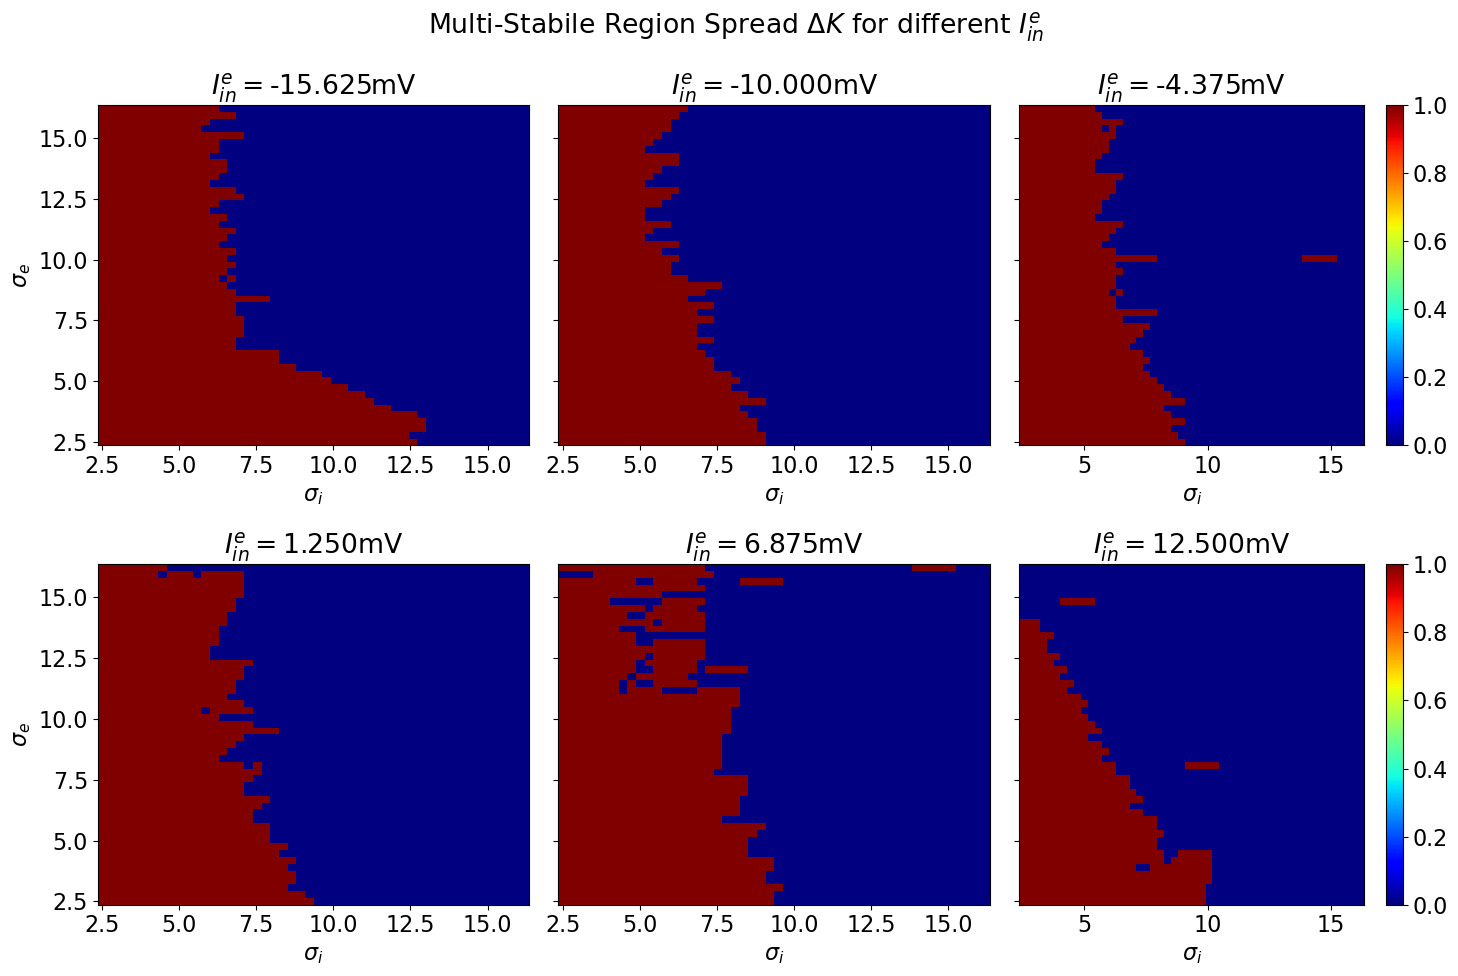

In [62]:
fileName = 'Scene02_MultiStable_DeltaK_HeatMap.png'

smoothDeltK = deepcopy(deltaK_arr)

for nI in range(nIvals):
    for nSE in range(nSigEvals):
        smoothDeltK[nI, nSE, :] = smooth(smoothDeltK[nI, nSE, :], nWindow=7, polyOrder=3)

encodeDeltaK = deepcopy(smoothDeltK)
encodeDeltaK[encodeDeltaK > 0.000] = 1
encodeDeltaK[encodeDeltaK <= 0.000] = 0

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

nRow = 0
nCol = 0

for nI in range(0, nIvals, 9):

    pcos = axs[nRow, nCol].pcolormesh(sigmai_uniq, sigmae_uniq, encodeDeltaK[nI, :, :], cmap='jet')
    axs[nRow, nCol].set_xlabel(r"$\sigma_i$")
    axs[nRow, nCol].set_title(r"$I_{in}^e = $" + f"{I_uniq[nI]:.3f}mV")

    if nCol == 0:
        axs[nRow, nCol].set_ylabel(r"$\sigma_e$")

    if nCol == 2:
        fig.colorbar(pcos, orientation='vertical')

    if nCol < 2:
        nCol += 1
    else:
        nCol = 0
        nRow += 1

fig.suptitle("Multi-Stabile Region Spread " + r"$\Delta K$ for different $I_{in}^e$")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), dpi=600)
plt.show()



In [78]:
## Calculate the multi-stability region as delta K vs. sigma for different I values

fileName = 'MultiStable_DeltaI.pkl'

if os.path.isfile(os.path.join(load_dir, fileName)):
    print("File FOUND!")
    with open(os.path.join(load_dir, fileName), 'rb') as f:
        ResultsDict = pickle.load(f)
    
    deltaI_arr = ResultsDict['DeltaI']
    MultiI = ResultsDict['MultiI']

else:

    deltaI_arr = np.zeros((nKvals, nSigEvals, nSigIvals))   # region width in terms of K
    MultiI = np.zeros((nKvals, nSigEvals, nSigIvals))       # no. of multi-stability regions

    for nK in range (0, nKvals):
        K = K_uniq[nK]

        if nK % 10 == 0:
            print(f'Evaluating multi-region width for K = {K:.3f}')
        for nSE, sigE in enumerate(sigmae_uniq):
            for nSI, sigI in enumerate(sigmai_uniq):
            
                df_sub = fp_df[(fp_df['sig_e'] == sigE) & (fp_df['sig_i'] == sigI) & (fp_df['K'] == K)]

                fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

                I = np.array(list(fp_counts_dict.keys()))
                Isort = np.argsort(I)
                I = I[Isort]

                FP_count = np.array(list(fp_counts_dict.values()))
                FP_count = FP_count[Isort]

                MultiR_id = np.where(FP_count > 1)[0]

                if len(MultiR_id) == 0:
                    continue

                Mult_diffid = np.diff(MultiR_id)

                markers = np.where(Mult_diffid > 5)[0] + 1
                nRegions = len(markers)

                # if there are multiple multi-stable regions in the system delta K is claculated as sum of delta K over all regions
                if nRegions:
                    segment_delt = []
                    start_marker = 0

                    for i in range(nRegions + 1):
                        if i !=  nRegions:
                            marker = markers[i]
                            segment = MultiR_id[start_marker:marker]
                        else:
                            segment = MultiR_id[start_marker:]
                        
                        if i < nRegions:
                            start_marker = marker

                        segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0
                    
                    deltaI_arr[nK, nSE, nSI] = sum(segment_delt)
                    MultiI[nK, nSE, nSI] = len(segment_delt)

                else:
                    MultiI[nK, nSE, nSI] += 1
                    deltaI_arr[nK, nSE, nSI] = I[MultiR_id[-1]] - I[MultiR_id[0]]

    ResultsDict = {
                    'DeltaI': deltaI_arr,
                    'MultiI': MultiI
                }
    
    with open(os.path.join(load_dir, fileName), 'wb') as f:
        pickle.dump(ResultsDict, f)     

Evaluating multi-region width for K = -1.000


Evaluating multi-region width for K = -0.600
Evaluating multi-region width for K = -0.200
Evaluating multi-region width for K = 0.200
Evaluating multi-region width for K = 0.600


In [79]:
# K0indx = np.where(K_uniq == 0)[0][0]
# MultiI = np.delete(MultiI, (K0indx), axis=0)

# K = K_uniq[K0indx]

# K0df = fp_df[['I', 'K', 'sigma', 'ue1']]
# K0df = K0df[(K0df['K'] == K)]

# K0df = K0df.drop_duplicates(subset=['ue1'])

# Uncoupled = np.zeros(nSigvals)

# for nS, sigma_ in enumerate(sigma_uniq):
        
#     df_sub = K0df[(K0df['sigma'] == sigma_)]

#     fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

#     I = np.array(list(fp_counts_dict.keys()))
#     Isort = np.argsort(I)
#     I = I[Isort]

#     FP_count = np.array(list(fp_counts_dict.values()))
#     FP_count = FP_count[Isort]

#     MultiR_id = np.where(FP_count > 1)[0]

#     if len(MultiR_id) == 0:
#         continue

#     Mult_diffid = np.diff(MultiR_id)

#     markers = np.where(Mult_diffid > 4)[0] + 1
#     nRegions = len(markers)

#     if nRegions:
#         segment_delt = []
#         start_marker = 0

#         for i in range(nRegions + 1):
#             if i !=  nRegions:
#                 marker = markers[i]
#                 segment = MultiR_id[start_marker:marker]
#             else:
#                 segment = MultiR_id[start_marker:]
            
#             if i < nRegions:
#                 start_marker = marker

#             segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0

#         Uncoupled[nS] = max(segment_delt)

#     else:
#         Uncoupled[nS] = I[MultiR_id[-1]] - I[MultiR_id[0]]

# deltaI_arr[K0indx] = Uncoupled

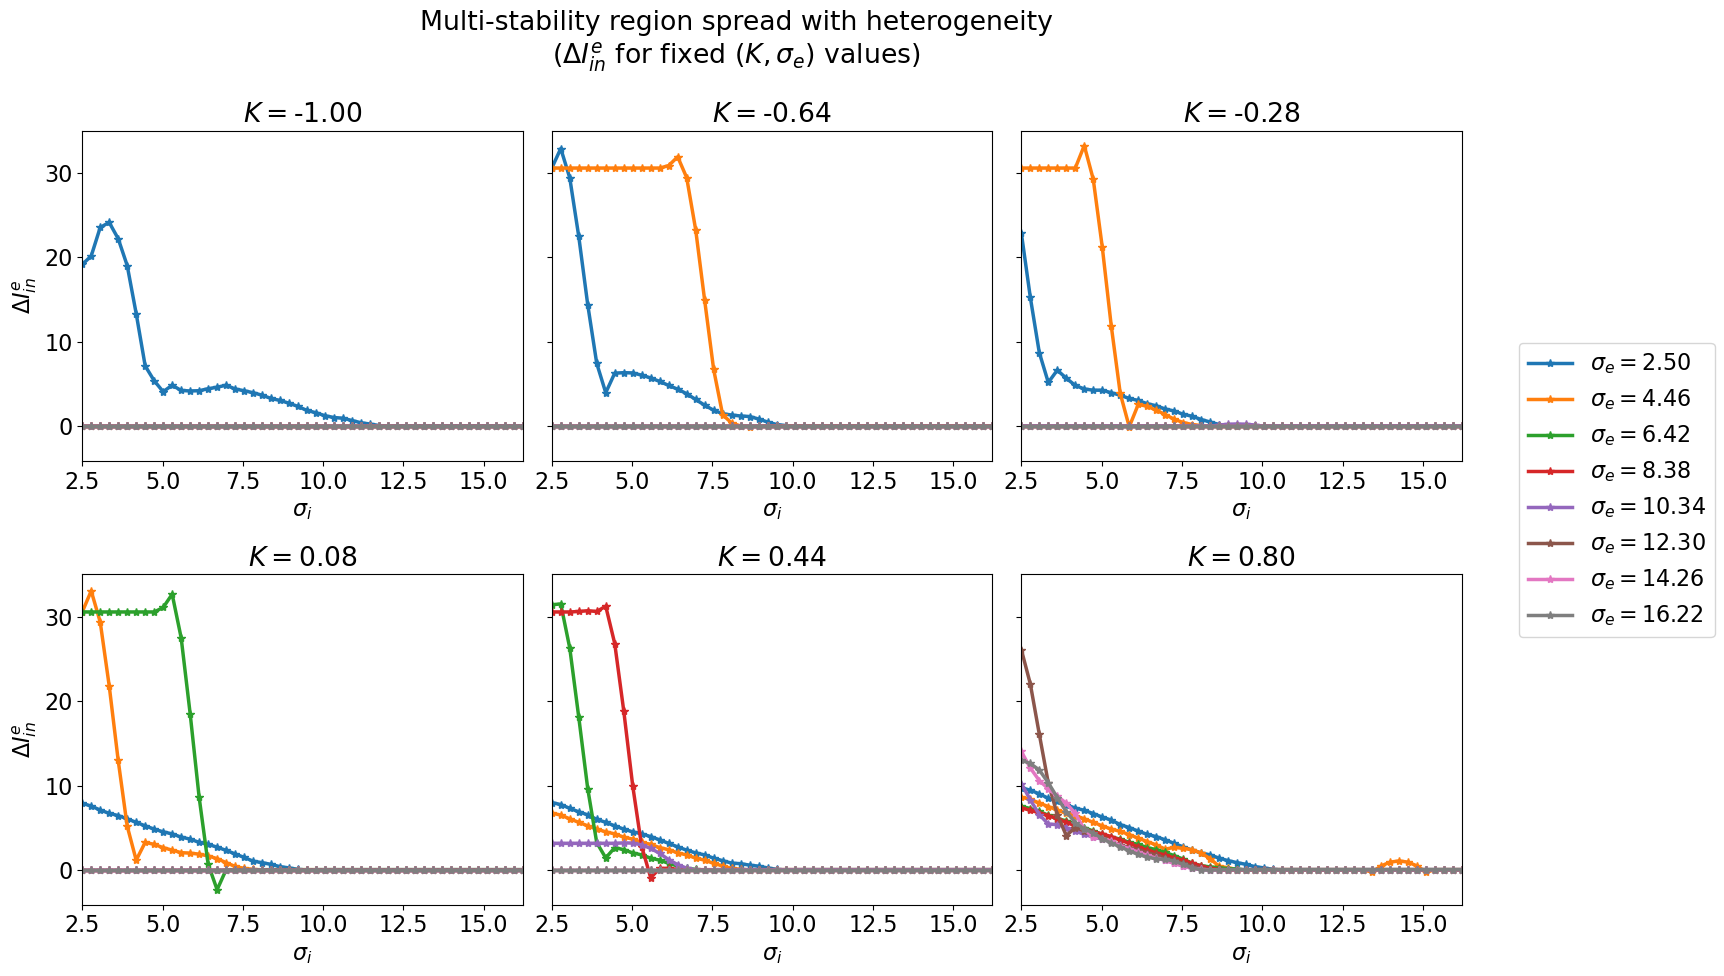

In [80]:
fileName = 'Scene02_MultiStable_DeltaI.png'

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

nRow = 0
nCol = 0

for nK in range(0, nKvals, 9):
    for nSE in range(0, nSigEvals, 7):
        if nRow == 1 and nCol == 2:
            axs[nRow, nCol].plot(sigmai_uniq, smooth(deltaI_arr[nK, nSE, :], 7, 3), '-*', linewidth=2.5, label=r"$\sigma_e = $" + f"{sigmae_uniq[nSE]:.2f}")
        else:
            axs[nRow, nCol].plot(sigmai_uniq, smooth(deltaI_arr[nK, nSE, :], 7, 3), '-*', linewidth=2.5)
    
    axs[nRow, nCol].set_title(r"$K = $" + f"{K_uniq[nK]:.2f}")
    axs[nRow, nCol].set_xlabel(r"$\sigma_i$")
    axs[nRow, nCol].set_xlim(sigmai_uniq[0], sigmai_uniq[-1])

    if nCol == 0:
        axs[nRow, nCol].set_ylabel(r"$\Delta I_{in}^e$")
    
    if nCol < 2:
        nCol += 1
    else:
        nCol = 0
        nRow += 1

fig.legend(loc = 'center right', bbox_to_anchor=(1.16, 0.5))
plt.suptitle("Multi-stability region spread with heterogeneity\n" + r"($\Delta I_{in}^e$ for fixed $(K, \sigma_e)$ values)")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), dpi=600)
plt.show()

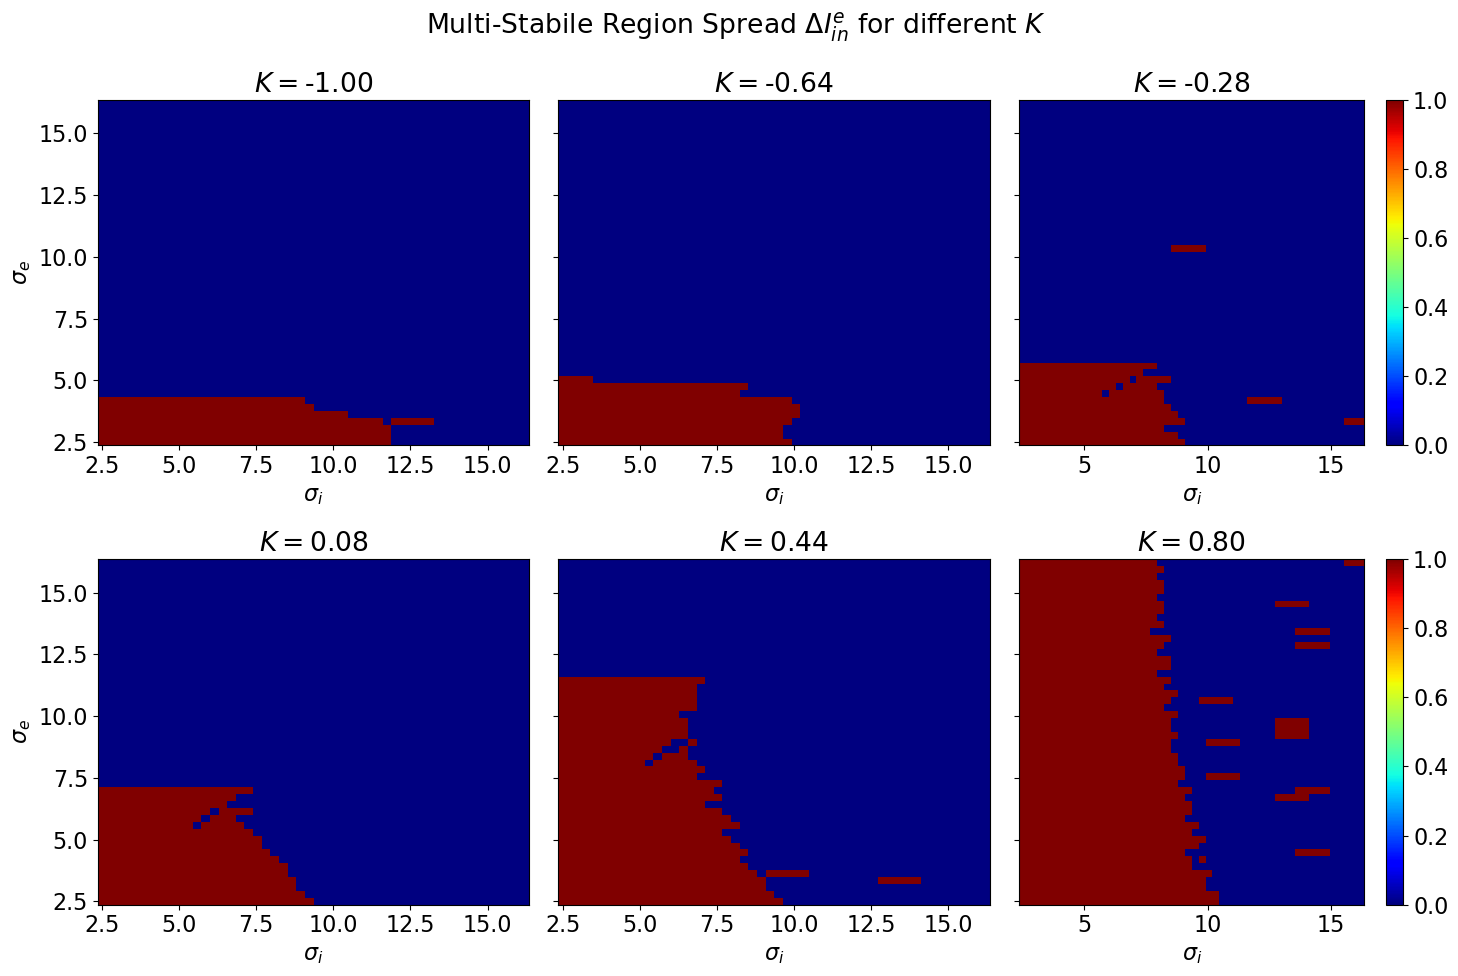

In [84]:
fileName = 'Scene02_MultiStable_DeltaI_HeatMap.png'

smoothDeltI = deepcopy(deltaI_arr)

for nK in range(nKvals):
    for nSE in range(nSigEvals):
        smoothDeltI[nK, nSE, :] = smooth(smoothDeltI[nK, nSE, :], nWindow=7, polyOrder=3)

encodeDeltaI = deepcopy(smoothDeltI)
encodeDeltaI[encodeDeltaI > 0.000] = 1
encodeDeltaI[encodeDeltaI <= 0.000] = 0

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

nRow = 0
nCol = 0

for nK in range(0, nKvals, 9):

    pcos = axs[nRow, nCol].pcolormesh(sigmai_uniq, sigmae_uniq, encodeDeltaI[nK, :, :], cmap='jet')
    axs[nRow, nCol].set_xlabel(r"$\sigma_i$")
    axs[nRow, nCol].set_title(r"$K = $" + f"{K_uniq[nK]:.2f}")

    if nCol == 0:
        axs[nRow, nCol].set_ylabel(r"$\sigma_e$")

    if nCol == 2:
        fig.colorbar(pcos, orientation='vertical')

    if nCol < 2:
        nCol += 1
    else:
        nCol = 0
        nRow += 1

fig.suptitle("Multi-Stabile Region Spread " + r"$\Delta I_{in}^e$ for different $K$")
plt.tight_layout()

plt.savefig(os.path.join(save_dir, fileName), dpi=600)
plt.show()

In [4]:
## Dimension reduction
from sklearn.decomposition import KernelPCA

root_dir = './results'
type_dir = 'fp'
scene_dir = 'scene02'
save_str = datetime.datetime(2024, 2, 22)

load_dir = os.path.join(root_dir, type_dir, scene_dir, f'exp-{save_str.year}-{save_str.month}-{save_str.day}')

In [24]:
filePaths = sorted(glob.glob(os.path.join(load_dir, "*.pkl")))
print(f"No. of files = {len(filePaths)}")

# sorting based on sigma value
sigmae_lookup = {}
sigmai_lookup = {}
I_lookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath)
    sige_val = float(baseName.split('_')[3])
    sigi_val = float(baseName.split('_')[4])
    I_val = float(baseName.split('_')[-1][:-6])

    if sige_val not in sigmae_lookup.keys():
        sigmae_lookup[sige_val] = [filePath]
        sigmai_lookup[sige_val] = [sigi_val]
        I_lookup[sige_val] = [I_val]
    else:
        sigmae_lookup[sige_val].append(filePath)
        sigmai_lookup[sige_val].append(sigi_val)
        I_lookup[sige_val].append(I_val)
    

for key, vals in I_lookup.items():
    I_vals = np.array(vals)
    Isort = np.argsort(I_vals)

    sigmae_lookup[key] = np.array(sigmae_lookup[key])[Isort]
    # sigmai_lookup[key] = np.array(sigmai_lookup[key])[Isort]

sigmae_vals = np.array(list(sigmae_lookup.keys()))
sigeSort = np.argsort(sigmae_vals)

filePathsSort = []

for n in sigeSort:
    sigma_key = sigmae_vals[n]
    filePathsSort += list(sigmae_lookup[sigma_key])

filePathsSort = np.array(filePathsSort)

No. of files = 210


In [15]:
def fpPlot(df, xVar='I', ifSave = False,  figsize=(25, 5), **plotparams):

    xlabel = plotparams.get('4Dxlabel')
    xlow = plotparams.get('xlow')
    xhigh = plotparams.get('xhigh')
    suptitle = plotparams.get('title')
    pathToimg = plotparams.get('path')
    
    plt.figure(figsize=figsize)

    plt.subplot(1, 5, 1)
    plt.scatter(df[xVar], df['ue1'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$U_e^1$"); plt.xlabel(xlabel)
    plt.xlim(xlow, xhigh)
    plt.title("Node (1) | E - population")

    plt.subplot(1, 5, 2)
    plt.scatter(df[xVar], df['ui1'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$U_i^1$"); plt.xlabel(xlabel)
    plt.xlim(xlow, xhigh)
    plt.title("Node (1) | I - population")

    plt.subplot(1, 5, 3)
    plt.scatter(df[xVar], df['ue2'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$U_e^2$"); plt.xlabel(xlabel)
    plt.xlim(xlow, xhigh)
    plt.title("Node (2) | E - population")

    plt.subplot(1, 5, 4)
    plt.scatter(df[xVar], df['ui2'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$U_i^2$"); plt.xlabel(xlabel)
    plt.xlim(xlow, xhigh)
    plt.title("Node (2) | I - population")


    plt.subplot(1, 5, 5)
    plt.scatter(df[xVar], df['U'], c=df['FP_types'], marker='.')
    plt.ylabel(r"$U$"); plt.xlabel(xlabel)
    plt.xlim(xlow, xhigh)
    plt.title("Fixed points in reduced dimension")
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=False)

    plt.suptitle(suptitle, fontsize=20)
    plt.tight_layout()

    if ifSave:
        plt.savefig(pathToimg, dpi=600)
        
    plt.show()

In [16]:
def dimreduction(dataDict, xVar='I', **params):
    dataD = {}
    dataD[xVar] = [x / params.get('gamma') for x in dataDict['fp_var']]

    for key, val in dataDict['fps'].items():
        dataD[key] = val
    
    dataDF = pd.DataFrame.from_dict(dataD)
    dataDF = dataDF[["ue1","ui1", "ue2", "ui2"]]

    PCA_INIT = KernelPCA(n_components=1, kernel='poly')
    U = PCA_INIT.fit_transform(dataDF)

    dataD['U'] = U.flatten()
    dataD['FP_types'] = dataDict['fp_types']['ue1']

    dataDF = pd.DataFrame.from_dict(dataD)

    return dataDF  

In [ ]:
for filePath in filePathsSort:
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    BaseName = os.path.basename(filePath)
    I = float(BaseName.split('_')[-1][:-6])
    Sige = float(BaseName.split('_')[3])
    Sigi = float(BaseName.split('_')[4])

    DF = dimreduction(DataDict, xVar='I', **params)

    plot_dict = {
                '4Dxlabel': r"$I_{in}^e$",
                'xlow': min(DataDict['fp_var']) / params['gamma'],
                'xhigh': max(DataDict['fp_var']) / params['gamma'],
                'title': 'Fixed point analysis for ' + r"$\sigma_e$ = " + f"{Sige:.3f} " + r"$\sigma_i$ = " + f"{Sigi:.3f} " +\
                     r"$I^{in}_e$ = " + f"{I:.2f}",
                'path': None
    }
    fpPlot(df=DF, xVar='I', ifSave = False,  figsize=(25, 5), **plot_dict)

In [ ]:
## Scenario 3 v1 reduction

root_dir = './results'
type_dir = 'fp'
scene_dir = 'scene03'
save_str = datetime.datetime(2024, 1, 18)

load_dir = os.path.join(root_dir, type_dir, scene_dir, f'exp-{save_str.year}-{save_str.month}-{save_str.day}')
file_name = f'{scene_dir}_data.pkl'

In [ ]:
with open(os.path.join(load_dir, file_name), 'rb') as file_:
    fp_data = pickle.load(file_)

In [ ]:
FPdf = pd.DataFrame.from_dict(fp_data)
print(FPdf.head(5))

        I    K  sig_e  sig_i1  sig_i2     ue1      ui1      ue2      ui2  \
0 -15.625 -1.0    2.5     2.5     2.5 -7.7586 -31.0480  -7.7586 -31.0480   
1 -15.625 -1.0    2.5     2.5     2.5 -2.7673  -5.6879  -2.7673  -5.6879   
2 -15.625 -1.0    2.5     2.5     2.5 -3.3039 -13.3167  -2.7566  -5.5316   
3 -15.625 -1.0    2.5     2.5     2.5 -2.7566  -5.5316  -3.3039 -13.3167   
4 -15.625 -1.0    2.5     2.5     2.5 -2.6571  -4.1608 -12.9679 -31.2500   

  FP_type  
0     red  
1  purple  
2  purple  
3  purple  
4  purple  


In [ ]:
I_uniq = FPdf['I'].unique()
K_uniq = FPdf['K'].unique()
Sige_uniq = FPdf['sig_e'].unique()
Sigi1_uniq = FPdf['sig_i1'].unique()
Sigi2_uniq = FPdf['sig_i2'].unique()

print(len(I_uniq), len(K_uniq), len(Sige_uniq), len(Sigi1_uniq), len(Sigi2_uniq))

10 20 20 20 20


In [ ]:
FPsubdf = FPdf[(FPdf['I'] == I_uniq[-1]) & (FPdf['K'] == K_uniq[10]) & (FPdf['sig_i1'] == Sigi1_uniq[0]) & (FPdf['sig_i2'] == Sigi2_uniq[0])]

In [ ]:
from sklearn.decomposition import KernelPCA

fpData = FPsubdf[["ue1","ui1", "ue2", "ui2"]]
pca = KernelPCA(n_components=1, kernel='poly')
fpDatapca = pca.fit_transform(fpData)

/tmp/ipykernel_926980/3715932823.py:16: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 3, 3)


<Figure size 2500x500 with 0 Axes>

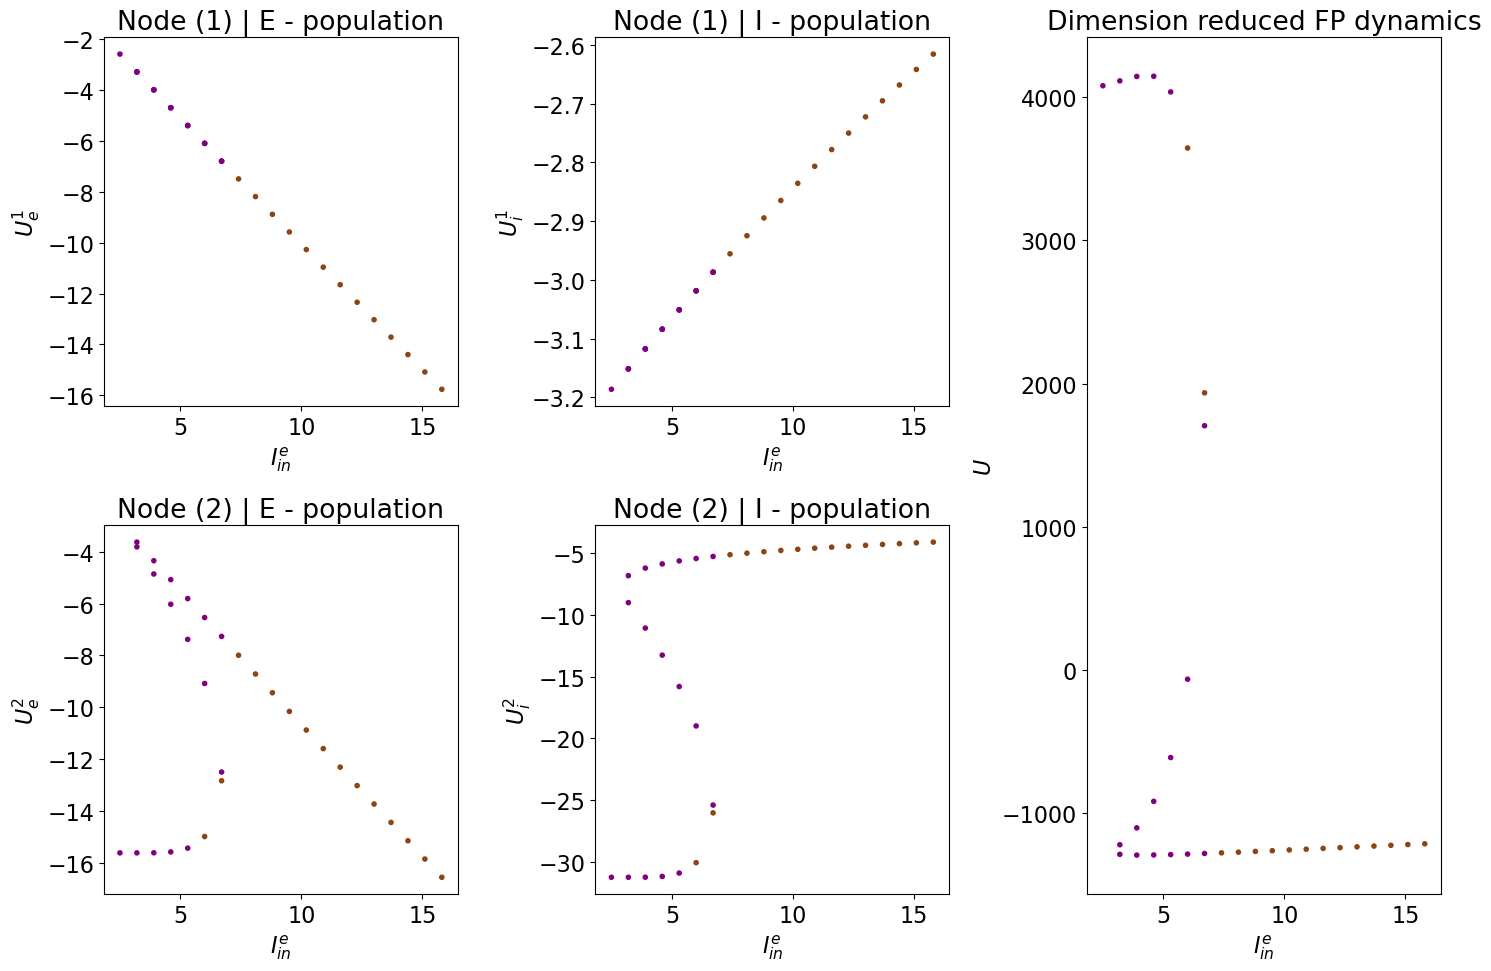

In [ ]:
plt.figure(figsize=(25, 5))
fig, axs = plt.subplots(2, 3, figsize = (15, 10))

plt.subplot(2, 3, 1)
plt.scatter(FPsubdf['sig_e'], FPsubdf['ue1'], c=FPsubdf['FP_type'], marker='.')
plt.ylabel(r"$U_e^1$")
plt.xlabel(r"$I_{in}^e$")
plt.title("Node (1) | E - population")

plt.subplot(2, 3, 2)
plt.scatter(FPsubdf['sig_e'], FPsubdf['ui1'], c=FPsubdf['FP_type'], marker='.')
plt.ylabel(r"$U_i^1$")
plt.xlabel(r"$I_{in}^e$")
plt.title("Node (1) | I - population")

plt.subplot(1, 3, 3)
plt.scatter(FPsubdf['sig_e'], fpDatapca, c=FPsubdf['FP_type'], marker='.')
plt.ylabel(r"$U$")
plt.xlabel(r"$I_{in}^e$")
plt.title("Dimension reduced FP dynamics")

plt.subplot(2, 3, 4)
plt.scatter(FPsubdf['sig_e'], FPsubdf['ue2'], c=FPsubdf['FP_type'], marker='.')
plt.ylabel(r"$U_e^2$")
plt.xlabel(r"$I_{in}^e$")
plt.title("Node (2) | E - population")

plt.subplot(2, 3, 5)
plt.scatter(FPsubdf['sig_e'], FPsubdf['ui2'], c=FPsubdf['FP_type'], marker='.')
plt.ylabel(r"$U_i^2$")
plt.xlabel(r"$I_{in}^e$")
plt.title("Node (2) | I - population")

# plt.suptitle('Fixed point analysis for ' + r"$\sigma$ = " + f"{sig_val:.3f} " + r"$K$ = " + f"{k_val:.2f}")
plt.tight_layout()

In [ ]:
FPsubdfe2_sort

NameError: name 'FPsubdfe2_sort' is not defined